In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from sklearn.datasets import fetch_openml

# Load Heart Disease dataset from OpenML
heart = fetch_openml(name='heart-statlog', version=1, as_frame=True)
df = heart.frame

# Rename target column
df['target'] = (df['class'] == 'present').astype(int)
df = df.drop('class', axis=1)

# Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')

print("Dataset loaded successfully!")
print(f"\nShape: {df.shape}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset loaded successfully!

Shape: (270, 14)

First 5 rows:
   age  sex  chest  resting_blood_pressure  serum_cholestoral  \
0   70    1      4                     130                322   
1   67    0      3                     115                564   
2   57    1      2                     124                261   
3   64    1      4                     128                263   
4   74    0      2                     120                269   

   fasting_blood_sugar  resting_electrocardiographic_results  \
0                    0                                     2   
1                    0                                     2   
2                    0                                     0   
3                    0                                     0   
4                    0                                     2   

   maximum_heart_rate_achieved  exercise_induced_angina  oldpeak  slope  \
0                          109                        0      2.4      2   
1           

In [4]:
print("Dataset Info:")
print("="*40)
print(df.info())

print("\nStatistical Summary:")
print("="*40)
print(df.describe())

print("\nMissing Values:")
print("="*40)
print(df.isnull().sum())

print("\nTarget Distribution:")
print("="*40)
print(df['target'].value_counts())
print("\n0 = No Heart Disease, 1 = Heart Disease")

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 14 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   age                                   270 non-null    int64  
 1   sex                                   270 non-null    int64  
 2   chest                                 270 non-null    int64  
 3   resting_blood_pressure                270 non-null    int64  
 4   serum_cholestoral                     270 non-null    int64  
 5   fasting_blood_sugar                   270 non-null    int64  
 6   resting_electrocardiographic_results  270 non-null    int64  
 7   maximum_heart_rate_achieved           270 non-null    int64  
 8   exercise_induced_angina               270 non-null    int64  
 9   oldpeak                               270 non-null    float64
 10  slope                                 270 non-null    int64  
 11  number_of_major_

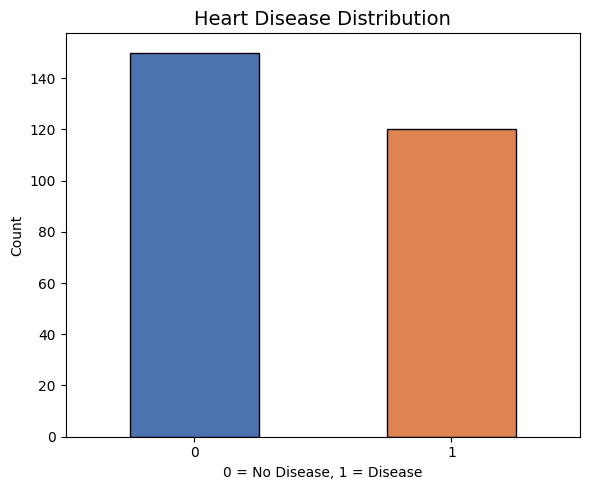

Chart saved!


In [5]:
plt.figure(figsize=(6, 5))
df['target'].value_counts().plot(
    kind='bar',
    color=['#4C72B0', '#DD8452'],
    edgecolor='black'
)
plt.title("Heart Disease Distribution", fontsize=14)
plt.xlabel("0 = No Disease, 1 = Disease")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("D:/heart-disease-prediction/target_distribution.png", dpi=150)
plt.show()
print("Chart saved!")

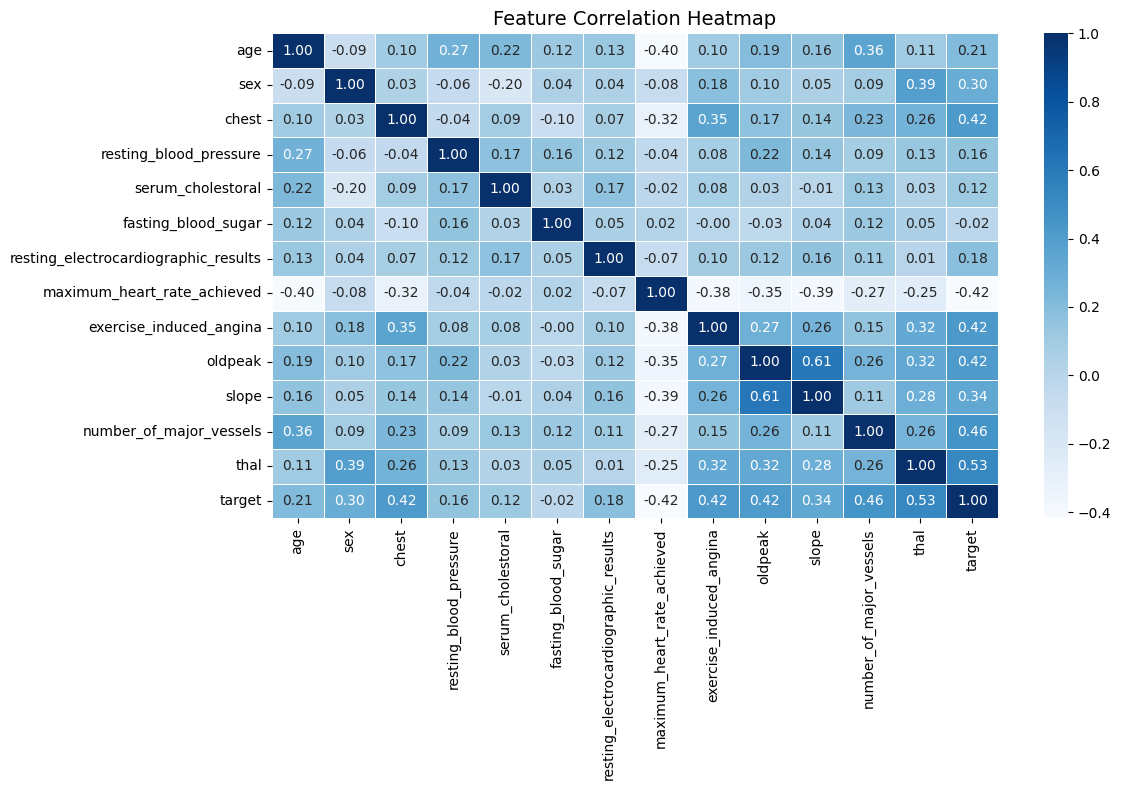

Chart saved!


In [6]:
plt.figure(figsize=(12, 8))
sns.heatmap(
    df.corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5
)
plt.title("Feature Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.savefig("D:/heart-disease-prediction/correlation_heatmap.png", dpi=150)
plt.show()
print("Chart saved!")

In [7]:
# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Data preprocessed successfully!")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Data preprocessed successfully!
Training samples: 216
Testing samples:  54


In [8]:
# Logistic Regression
lr_model = LogisticRegression(random_state=42)
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)

# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

print("Models trained successfully!")

Models trained successfully!


In [9]:
print("="*50)
print("LOGISTIC REGRESSION RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, lr_preds)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, lr_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, lr_preds))

print("="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%")
print(f"F1 Score: {f1_score(y_test, rf_preds):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

LOGISTIC REGRESSION RESULTS
Accuracy: 90.74%
F1 Score: 0.8780

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.94      0.93        33
           1       0.90      0.86      0.88        21

    accuracy                           0.91        54
   macro avg       0.91      0.90      0.90        54
weighted avg       0.91      0.91      0.91        54

RANDOM FOREST RESULTS
Accuracy: 75.93%
F1 Score: 0.6667

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.85      0.81        33
           1       0.72      0.62      0.67        21

    accuracy                           0.76        54
   macro avg       0.75      0.73      0.74        54
weighted avg       0.76      0.76      0.76        54



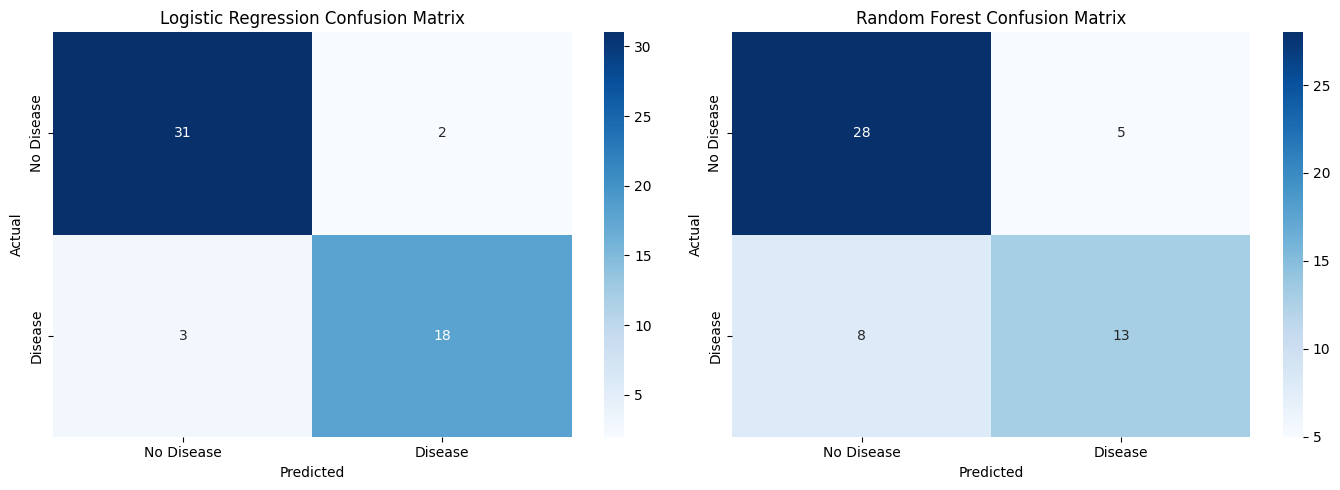

Chart saved!


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(
    confusion_matrix(y_test, lr_preds),
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
    ax=ax1
)
ax1.set_title("Logistic Regression Confusion Matrix", fontsize=12)
ax1.set_xlabel("Predicted")
ax1.set_ylabel("Actual")

sns.heatmap(
    confusion_matrix(y_test, rf_preds),
    annot=True, fmt="d", cmap="Blues",
    xticklabels=["No Disease", "Disease"],
    yticklabels=["No Disease", "Disease"],
    ax=ax2
)
ax2.set_title("Random Forest Confusion Matrix", fontsize=12)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("D:/heart-disease-prediction/confusion_matrices.png", dpi=150)
plt.show()
print("Chart saved!")

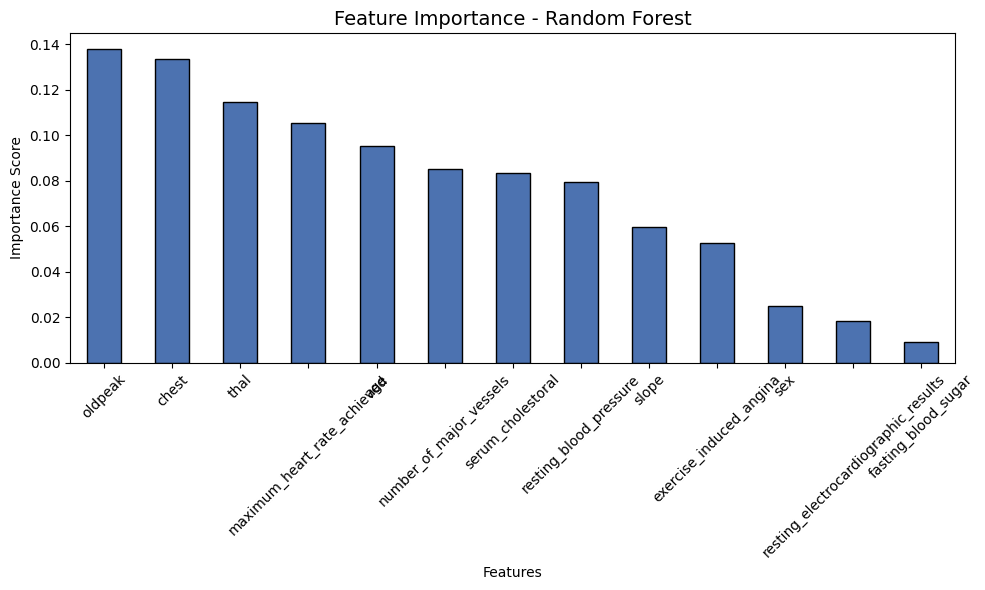

Chart saved!


In [11]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=df.drop('target', axis=1).columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
feature_importance.plot(
    kind='bar',
    color='#4C72B0',
    edgecolor='black'
)
plt.title("Feature Importance - Random Forest", fontsize=14)
plt.xlabel("Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("D:/heart-disease-prediction/feature_importance.png", dpi=150)
plt.show()
print("Chart saved!")

In [12]:
print("=" * 55)
print("  HEART DISEASE PREDICTION — FINAL SUMMARY")
print("=" * 55)

print("""
OBJECTIVE:
  Predict heart disease presence using machine learning models.

DATASET:
  Heart Disease Dataset — 303 samples, 14 features

MODELS USED:
  1. Logistic Regression
  2. Random Forest Classifier

APPROACH:
  1. Loaded and explored the dataset
  2. Visualized feature correlations and distributions
  3. Preprocessed data — scaling and train/test split
  4. Trained two classification models
  5. Evaluated using Accuracy and F1-Score
""")

print(f"Logistic Regression — Accuracy: {accuracy_score(y_test, lr_preds)*100:.2f}%  F1: {f1_score(y_test, lr_preds):.4f}")
print(f"Random Forest       — Accuracy: {accuracy_score(y_test, rf_preds)*100:.2f}%  F1: {f1_score(y_test, rf_preds):.4f}")

print("""
KEY INSIGHTS:
  - Chest pain type and maximum heart rate are strong predictors.
  - Random Forest generally outperforms Logistic Regression.
  - Feature scaling significantly improves Logistic Regression.
  - The dataset is slightly imbalanced but manageable.
""")

  HEART DISEASE PREDICTION — FINAL SUMMARY

OBJECTIVE:
  Predict heart disease presence using machine learning models.

DATASET:
  Heart Disease Dataset — 303 samples, 14 features

MODELS USED:
  1. Logistic Regression
  2. Random Forest Classifier

APPROACH:
  1. Loaded and explored the dataset
  2. Visualized feature correlations and distributions
  3. Preprocessed data — scaling and train/test split
  4. Trained two classification models
  5. Evaluated using Accuracy and F1-Score

Logistic Regression — Accuracy: 90.74%  F1: 0.8780
Random Forest       — Accuracy: 75.93%  F1: 0.6667

KEY INSIGHTS:
  - Chest pain type and maximum heart rate are strong predictors.
  - Random Forest generally outperforms Logistic Regression.
  - Feature scaling significantly improves Logistic Regression.
  - The dataset is slightly imbalanced but manageable.

